In [11]:
import csv
import jiwer
import torchaudio
import pandas as pd
from tqdm import tqdm
from wav2vec2decoder import Wav2Vec2Decoder
import matplotlib.pyplot as plt

In [13]:
decoder = Wav2Vec2Decoder(lm_model_path=None)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 19821.06it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
with open("data/librispeech_test_other/manifest.csv") as f:
    samples = list(csv.DictReader(f))

## Greedy vs. Beam Search

In [15]:
references, greedy_hyps, beam_hyps = [], [], []

for row in tqdm(samples):
    audio, sr = torchaudio.load(row["path"])
    references.append(row["text"])
    greedy_hyps.append(decoder.decode(audio, method="greedy"))
    beam_hyps.append(decoder.decode(audio, method="beam"))

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [04:30<00:00,  1.35s/it]


In [16]:
results = pd.DataFrame({
    "Method": ["greedy_decode", "beam_search_decode"],
    "WER": [
        jiwer.wer(references, greedy_hyps),
        jiwer.wer(references, beam_hyps),
    ],
    "CER": [
        jiwer.cer(references, greedy_hyps),
        jiwer.cer(references, beam_hyps),
    ],
})

results.style.format({"WER": "{:.2%}", "CER": "{:.2%}"})

,Method,WER,CER
0,greedy_decode,11.22%,3.81%
1,beam_search_decode,11.15%,3.78%


## Beam width change

In [17]:
import time

with open("data/librispeech_test_other/manifest.csv") as f:
    samples = list(csv.DictReader(f))

beam_widths = [1, 3, 10, 50]
beam_rows = []
dec = Wav2Vec2Decoder(lm_model_path=None)

for bw in beam_widths:
    dec.beam_width = bw
    refs, hyps = [], []
    t0 = time.time()
    for row in tqdm(samples, desc=f"beam_width={bw}"):
        audio, sr = torchaudio.load(row["path"])
        refs.append(row["text"])
        hyps.append(dec.decode(audio, method="beam"))
    elapsed = time.time() - t0
    beam_rows.append({
        "beam_width": bw,
        "WER": jiwer.wer(refs, hyps),
        "CER": jiwer.cer(refs, hyps),
        "time_sec": round(elapsed, 1),
    })

beam_df = pd.DataFrame(beam_rows)
beam_df.style.format({"WER": "{:.2%}", "CER": "{:.2%}"})

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23555.39it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam_width=50: 100%|██████████| 200/200 [15:53<00:00,  4.77s/it]


,beam_width,WER,CER,time_sec
0,1,11.24%,3.80%,127.400000
1,3,11.15%,3.78%,164.300000
2,10,11.07%,3.77%,272.700000
3,50,11.10%,3.77%,953.300000


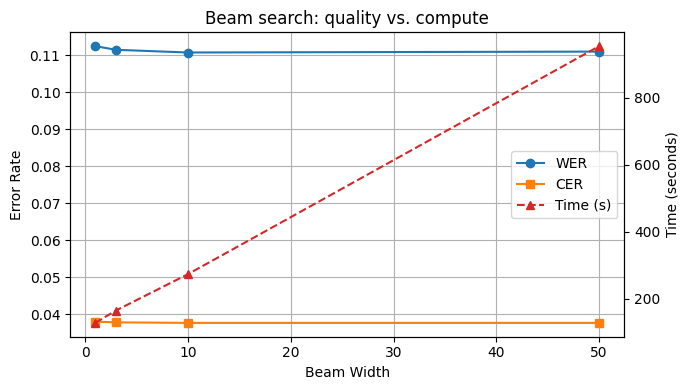

In [18]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(beam_df["beam_width"], beam_df["WER"], marker="o", color="tab:blue", label="WER")
ax1.plot(beam_df["beam_width"], beam_df["CER"], marker="s", color="tab:orange", label="CER")
ax2.plot(beam_df["beam_width"], beam_df["time_sec"], marker="^", color="tab:red", linestyle="--", label="Time (s)")

ax1.set_xlabel("Beam Width")
ax1.set_ylabel("Error Rate")
ax2.set_ylabel("Time (seconds)")
ax1.set_title("Beam search: quality vs. compute")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.grid(True)
plt.tight_layout()
plt.show()

## Temperature change (beam search decoding)

In [19]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
temp_rows = []
dec = Wav2Vec2Decoder(lm_model_path=None)

for T in temperatures:
    dec.temperature = T
    refs, hyps = [], []
    for row in tqdm(samples, desc=f"T={T}"):
        audio, sr = torchaudio.load(row["path"])
        refs.append(row["text"])
        hyps.append(dec.decode(audio, method="beam"))
    temp_rows.append({
        "temperature": T,
        "WER": jiwer.wer(refs, hyps),
        "CER": jiwer.cer(refs, hyps),
    })

temp_df = pd.DataFrame(temp_rows)
temp_df.style.format({"WER": "{:.2%}", "CER": "{:.2%}"})

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23557.26it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
T=2.0: 100%|██████████| 200/200 [02:38<00:00,  1.27it/s]


,temperature,WER,CER
0,0.500000,11.10%,3.80%
1,0.800000,11.17%,3.81%
2,1.000000,11.15%,3.78%
3,1.200000,11.20%,3.79%
4,1.500000,11.05%,3.73%
5,2.000000,11.17%,3.75%


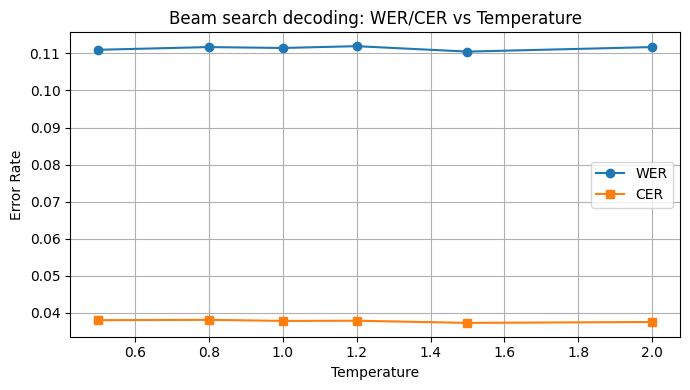

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(temp_df["temperature"], temp_df["WER"], marker="o", label="WER")
ax.plot(temp_df["temperature"], temp_df["CER"], marker="s", label="CER")
ax.set_xlabel("Temperature")
ax.set_ylabel("Error Rate")
ax.set_title("Beam search decoding: WER/CER vs Temperature")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Shallow fusion: alpha / beta sweep

In [21]:
import numpy as np
import torch

base_dec = Wav2Vec2Decoder(lm_model_path=None)

refs = []
all_logits = []
for row in tqdm(samples, desc="precompute logits"):
    audio, sr = torchaudio.load(row["path"])
    refs.append(row["text"])
    inputs = base_dec.processor(audio, return_tensors="pt", sampling_rate=16000)
    with torch.no_grad():
        logits = base_dec.model(inputs.input_values.squeeze(0)).logits[0]
    all_logits.append(logits)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 26501.92it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
precompute logits: 100%|██████████| 200/200 [01:43<00:00,  1.94it/s]


In [24]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]

wer_grid = np.zeros((len(alphas), len(betas)))
cer_grid = np.zeros((len(alphas), len(betas)))

dec = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa")

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        dec.alpha = a
        dec.beta = b
        hyps = []
        for logits in tqdm(all_logits, desc=f"a={a},b={b}", leave=False):
            hyps.append(dec.beam_search_with_lm(logits))
        wer_grid[i, j] = jiwer.wer(refs, hyps)
        cer_grid[i, j] = jiwer.cer(refs, hyps)
        print(f"alpha={a}, beta={b} => WER={wer_grid[i,j]:.2%}, CER={cer_grid[i,j]:.2%}")

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 21196.99it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


alpha=0.01, beta=0.0 => WER=11.15%, CER=3.79%


alpha=0.01, beta=0.5 => WER=11.07%, CER=3.77%


alpha=0.01, beta=1.0 => WER=11.32%, CER=3.81%


alpha=0.01, beta=1.5 => WER=11.42%, CER=3.82%


...

alpha=2.0, beta=1.5 => WER=11.76%, CER=3.95%


alpha=5.0, beta=0.0 => WER=98.12%, CER=97.58%


alpha=5.0, beta=0.5 => WER=96.16%, CER=95.53%


alpha=5.0, beta=1.0 => WER=95.62%, CER=95.01%


alpha=5.0, beta=1.5 => WER=92.03%, CER=90.75%


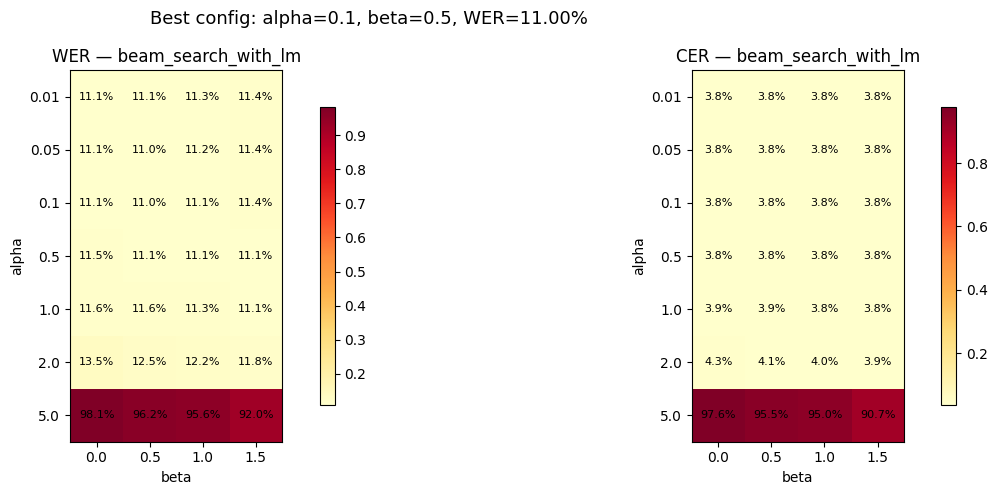

In [25]:
best_idx = np.unravel_index(np.argmin(wer_grid), wer_grid.shape)
best_alpha, best_beta = alphas[best_idx[0]], betas[best_idx[1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title in [(ax1, wer_grid, "WER"), (ax2, cer_grid, "CER")]:
    im = ax.imshow(grid, cmap="YlOrRd")
    ax.set_xticks(range(len(betas)), [str(b) for b in betas])
    ax.set_yticks(range(len(alphas)), [str(a) for a in alphas])
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")
    ax.set_title(f"{title} — beam_search_with_lm")
    for ii in range(len(alphas)):
        for jj in range(len(betas)):
            ax.text(jj, ii, f"{grid[ii, jj]:.1%}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Best config: alpha={best_alpha}, beta={best_beta}, WER={wer_grid[best_idx]:.2%}", fontsize=13)
plt.tight_layout()
plt.show()

## 3-gram vs 4-gram LM comparison

In [26]:
lm_configs = [
    ("3-gram", "lm/3-gram.pruned.1e-7.arpa"),
    ("4-gram", "lm/4-gram.arpa"),
]

lm_rows = []
for name, path in lm_configs:
    dec = Wav2Vec2Decoder(lm_model_path=path, alpha=best_alpha, beta=best_beta)
    hyps = []
    for logits in tqdm(all_logits, desc=name):
        hyps.append(dec.beam_search_with_lm(logits))
    lm_rows.append({
        "LM": name,
        "alpha": best_alpha,
        "beta": best_beta,
        "WER": jiwer.wer(refs, hyps),
        "CER": jiwer.cer(refs, hyps),
    })

lm_df = pd.DataFrame(lm_rows)
lm_df.style.format({"WER": "{:.2%}", "CER": "{:.2%}"})

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 24183.87it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 26497.18it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

,LM,alpha,beta,WER,CER
0,3-gram,0.100000,0.500000,11.00%,3.76%
1,4-gram,0.100000,0.500000,11.02%,3.76%


## LM rescore: alpha / beta sweep

In [27]:
base_dec = Wav2Vec2Decoder(lm_model_path=None, beam_width=3)

all_beams = []
for logits in tqdm(all_logits, desc="beam search (return_beams)"):
    all_beams.append(base_dec.beam_search_decode(logits, return_beams=True))

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 20932.52it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam search (return_beams): 100%|██████████| 200/200 [00:56<00:00,  3.56it/s]


In [28]:
alphas_r = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas_r = [0.0, 0.5, 1.0, 1.5]

wer_rescore = np.zeros((len(alphas_r), len(betas_r)))
cer_rescore = np.zeros((len(alphas_r), len(betas_r)))

dec = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa")

for i, a in enumerate(alphas_r):
    for j, b in enumerate(betas_r):
        dec.alpha = a
        dec.beta = b
        hyps = [dec.lm_rescore(beams) for beams in all_beams]
        wer_rescore[i, j] = jiwer.wer(refs, hyps)
        cer_rescore[i, j] = jiwer.cer(refs, hyps)
        print(f"alpha={a}, beta={b} => WER={wer_rescore[i,j]:.2%}, CER={cer_rescore[i,j]:.2%}")

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23552.27it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


alpha=0.01, beta=0.0 => WER=11.15%, CER=3.79%
alpha=0.01, beta=0.5 => WER=11.12%, CER=3.77%
alpha=0.01, beta=1.0 => WER=11.10%, CER=3.77%
alpha=0.01, beta=1.5 => WER=11.10%, CER=3.77%
alpha=0.05, beta=0.0 => WER=11.15%, CER=3.79%
alpha=0.05, beta=0.5 => WER=11.12%, CER=3.77%
alpha=0.05, beta=1.0 => WER=11.10%, CER=3.77%
alpha=0.05, beta=1.5 => WER=11.10%, CER=3.77%
alpha=0.1, beta=0.0 => WER=11.15%, CER=3.79%
alpha=0.1, beta=0.5 => WER=11.10%, CER=3.77%
alpha=0.1, beta=1.0 => WER=11.10%, CER=3.77%
alpha=0.1, beta=1.5 => WER=11.10%, CER=3.77%
alpha=0.5, beta=0.0 => WER=11.22%, CER=3.80%
alpha=0.5, beta=0.5 => WER=11.15%, CER=3.79%
alpha=0.5, beta=1.0 => WER=11.15%, CER=3.78%
alpha=0.5, beta=1.5 => WER=11.10%, CER=3.77%
alpha=1.0, beta=0.0 => WER=11.46%, CER=3.83%
alpha=1.0, beta=0.5 => WER=11.29%, CER=3.81%
alpha=1.0, beta=1.0 => WER=11.15%, CER=3.79%
alpha=1.0, beta=1.5 => WER=11.15%, CER=3.79%
alpha=2.0, beta=0.0 => WER=11.59%, CER=3.84%
alpha=2.0, beta=0.5 => WER=11.56%, CER=3.84%
al

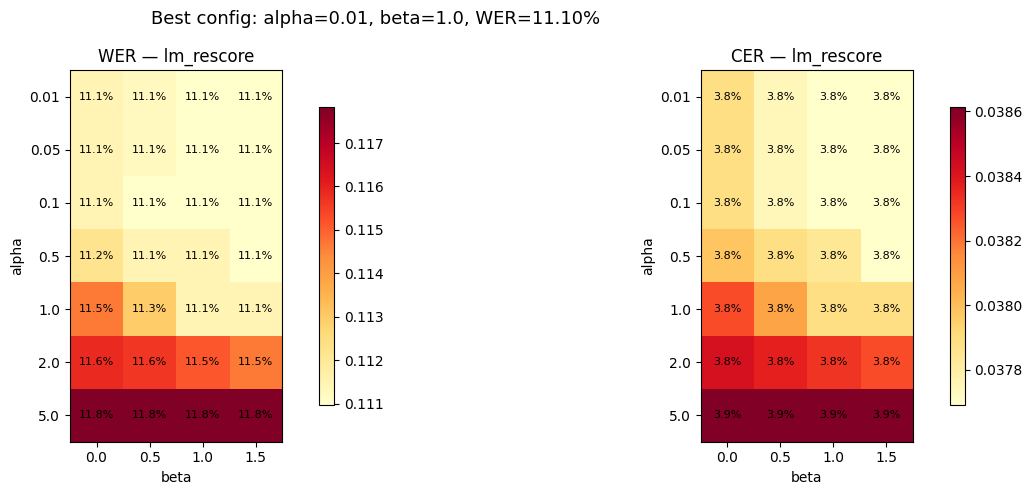

In [29]:
best_idx_r = np.unravel_index(np.argmin(wer_rescore), wer_rescore.shape)
best_alpha_r, best_beta_r = alphas_r[best_idx_r[0]], betas_r[best_idx_r[1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title in [(ax1, wer_rescore, "WER"), (ax2, cer_rescore, "CER")]:
    im = ax.imshow(grid, cmap="YlOrRd")
    ax.set_xticks(range(len(betas_r)), [str(b) for b in betas_r])
    ax.set_yticks(range(len(alphas_r)), [str(a) for a in alphas_r])
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")
    ax.set_title(f"{title} — lm_rescore")
    for ii in range(len(alphas_r)):
        for jj in range(len(betas_r)):
            ax.text(jj, ii, f"{grid[ii, jj]:.1%}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Best config: alpha={best_alpha_r}, beta={best_beta_r}, WER={wer_rescore[best_idx_r]:.2%}", fontsize=13)
plt.tight_layout()
plt.show()

## Qualitative comparison: beam vs shallow fusion vs rescore

In [30]:
sf_dec = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa",
    alpha=best_alpha, beta=best_beta,
)
rs_dec = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa",
    alpha=best_alpha_r, beta=best_beta_r,
)
beam_dec = Wav2Vec2Decoder(lm_model_path=None)

beam_hyps_all, sf_hyps_all, rs_hyps_all = [], [], []
for logits in tqdm(all_logits, desc="decoding"):
    beam_hyps_all.append(beam_dec.beam_search_decode(logits))
    sf_hyps_all.append(sf_dec.beam_search_with_lm(logits))
    beams = beam_dec.beam_search_decode(logits, return_beams=True)
    rs_hyps_all.append(rs_dec.lm_rescore(beams))

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 19271.62it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23555.39it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

In [31]:
def tag(hyp, ref, baseline):
    if hyp == ref:
        return "✓ exact match"
    hw = jiwer.wer(ref, hyp)
    bw = jiwer.wer(ref, baseline)
    if hw < bw:
        return "✓ improved"
    elif hw > bw:
        return "✗ degraded"
    return "— same WER"

interesting = []
for i in range(len(refs)):
    if beam_hyps_all[i] != sf_hyps_all[i] or beam_hyps_all[i] != rs_hyps_all[i]:
        interesting.append(i)

for idx in interesting[:10]:
    ref = refs[idx]
    bh = beam_hyps_all[idx]
    sf = sf_hyps_all[idx]
    rs = rs_hyps_all[idx]

    print(f"REF:  {ref}")
    print(f"BEAM: {bh}")
    print(f"SF:   {sf:<80s} {tag(sf, ref, bh)}")
    print(f"RS:   {rs:<80s} {tag(rs, ref, bh)}")
    print()

REF:  a fellow who was shut up in prison for life might do it he said but not in a case like this
BEAM: a fellow who as shut up in prison for life might doit he said but not in a case like this
SF:   a fellow who as shut up in prison for life might do it he said but not in a case like this ✓ improved
RS:   a fellow who as shut up in prison for life might doit he said but not in a case like this — same WER

REF:  the dull sound of departing steps and a low whistling sound coming down through the skylight window into the cabin where archy raystoke lay with his heavy eyelids pressed down by sleep
BEAM: the dull sound of departing steps and a low whistling sound coming down through the skylight window into the cabin where archy raystroke lay with his heavy eyelids pressed down by sleep
SF:   the dull sound of departing steps and a low whistling sound coming down through the skylight window into the cabin where archy raystroke lay with his heavy iyelids pressed down by sleep ✗ degraded
RS: 

## Cross-dataset comparison: LibriSpeech vs Earnings22

In [32]:
with open("data/earnings22_test/manifest.csv") as f:
    e22_samples = list(csv.DictReader(f))

e22_refs = []
e22_logits = []
e22_dec = Wav2Vec2Decoder(lm_model_path=None)
for row in tqdm(e22_samples, desc="earnings22 logits"):
    audio, sr = torchaudio.load(row["path"])
    e22_refs.append(row["text"])
    inputs = e22_dec.processor(audio, return_tensors="pt", sampling_rate=16000)
    with torch.no_grad():
        logits = e22_dec.model(inputs.input_values.squeeze(0)).logits[0]
    e22_logits.append(logits)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23796.83it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
earnings22 logits: 100%|██████████| 200/200 [01:41<00:00,  1.97it/s]


In [33]:
def eval_all_methods(logits_list, refs_list, desc=""):
    base_dec = Wav2Vec2Decoder(lm_model_path=None)
    sf_dec = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa",
        alpha=best_alpha, beta=best_beta,
    )
    rs_dec = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa",
        alpha=best_alpha_r, beta=best_beta_r,
    )

    greedy_h, beam_h, sf_h, rs_h = [], [], [], []
    for logits in tqdm(logits_list, desc=desc):
        greedy_h.append(base_dec.greedy_decode(logits))
        beam_h.append(base_dec.beam_search_decode(logits))
        sf_h.append(sf_dec.beam_search_with_lm(logits))
        beams = base_dec.beam_search_decode(logits, return_beams=True)
        rs_h.append(rs_dec.lm_rescore(beams))

    return {
        "Greedy": (jiwer.wer(refs_list, greedy_h), jiwer.cer(refs_list, greedy_h)),
        "Beam search": (jiwer.wer(refs_list, beam_h), jiwer.cer(refs_list, beam_h)),
        "Beam + 3-gram (shallow)": (jiwer.wer(refs_list, sf_h), jiwer.cer(refs_list, sf_h)),
        "Beam + 3-gram (rescore)": (jiwer.wer(refs_list, rs_h), jiwer.cer(refs_list, rs_h)),
    }

libri_results = eval_all_methods(all_logits, refs, desc="librispeech")
e22_results = eval_all_methods(e22_logits, e22_refs, desc="earnings22")

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 16549.58it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 19269.95it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

In [34]:
rows = []
for method in libri_results:
    lw, lc = libri_results[method]
    ew, ec = e22_results[method]
    rows.append({
        "Method": method,
        "LibriSpeech WER": lw,
        "LibriSpeech CER": lc,
        "Earnings22 WER": ew,
        "Earnings22 CER": ec,
    })

final_df = pd.DataFrame(rows)
final_df.style.format({
    "LibriSpeech WER": "{:.2%}",
    "LibriSpeech CER": "{:.2%}",
    "Earnings22 WER": "{:.2%}",
    "Earnings22 CER": "{:.2%}",
})

,Method,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
0,Greedy,11.22%,3.81%,54.97%,25.58%
1,Beam search,11.15%,3.78%,55.15%,25.46%
2,Beam + 3-gram (shallow),11.00%,3.76%,55.21%,25.46%
3,Beam + 3-gram (rescore),11.10%,3.77%,55.18%,25.47%


## Temperature sweep on Earnings22 (greedy vs shallow fusion)

In [35]:
temps = [0.5, 1.0, 1.5, 2.0]
e22_temp_rows = []

dec_greedy = Wav2Vec2Decoder(lm_model_path=None)
dec_sf = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa",
    alpha=best_alpha, beta=best_beta,
)

for T in temps:
    dec_greedy.temperature = T
    dec_sf.temperature = T
    greedy_h, sf_h = [], []
    for row in tqdm(e22_samples, desc=f"T={T}"):
        audio, sr = torchaudio.load(row["path"])
        greedy_h.append(dec_greedy.decode(audio, method="greedy"))
        sf_h.append(dec_sf.decode(audio, method="beam_lm"))
    e22_temp_rows.append({
        "temperature": T,
        "Greedy WER": jiwer.wer(e22_refs, greedy_h),
        "SF WER": jiwer.wer(e22_refs, sf_h),
    })

e22_temp_df = pd.DataFrame(e22_temp_rows)
e22_temp_df.style.format({"Greedy WER": "{:.2%}", "SF WER": "{:.2%}"})

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 21200.53it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 21196.99it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

,temperature,Greedy WER,SF WER
0,0.500000,54.97%,55.09%
1,1.000000,54.97%,55.21%
2,1.500000,54.97%,56.02%
3,2.000000,54.97%,56.20%


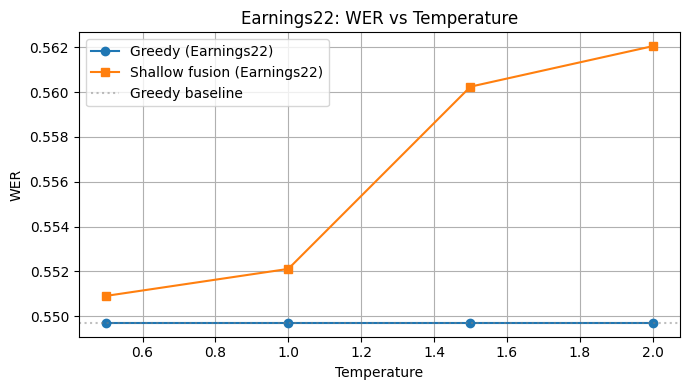

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e22_temp_df["temperature"], e22_temp_df["Greedy WER"], marker="o", label="Greedy (Earnings22)")
ax.plot(e22_temp_df["temperature"], e22_temp_df["SF WER"], marker="s", label="Shallow fusion (Earnings22)")
ax.axhline(y=e22_temp_df["Greedy WER"].iloc[0], color="gray", linestyle=":", alpha=0.5, label="Greedy baseline")
ax.set_xlabel("Temperature")
ax.set_ylabel("WER")
ax.set_title("Earnings22: WER vs Temperature")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()